### Alphawood Arboretum Species Breakdown

In [1]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
os.getcwd()

'c:\\Users\\tomas\\OneDrive\\Desktop\\College\\SOREMO\\chicago-tree-health\\Alphawood Arboretum'

In [18]:

base = Path('__file__').resolve().parent
df = pd.read_csv(base / 'iit_trees_corrected(filters).csv')

df

,tree_id,placemark_name,planting_cohort,established,common_name,scientific_name,additional_taxonomy,dbh_inches,dbh_raw,dbh_equiv,dbh_clean,dbh_status,is_multi_stem,source,community_tags,memorial,latitude,longitude
0,1702,1-2025 O,2025-O,False,Tupelo-Black,Nyssa sylvatica,NaN,1.0,1.0,1.0,1.0,new_planting,False,Plant,Planted by Openlands TreeKeepers spring 2025 c...,NaN,41.837635,-87.624176
1,1703,2-2025 O,2025-O,False,Tupelo-Black,Nyssa sylvatica,NaN,1.0,1.0,1.0,1.0,new_planting,False,Plant,Planted by Openlands TreeKeepers spring 2025 c...,NaN,41.837547,-87.624306
2,1704,4-2025 O,2025-O,False,Tupelo-Black,Nyssa sylvatica,NaN,1.0,1.0,1.0,1.0,new_planting,False,Plant,Planted by Openlands TreeKeepers spring 2025 c...,NaN,41.837479,-87.624176
3,1705,3-2025 O,2025-O,False,Tupelo-Black,Nyssa sylvatica,NaN,1.0,1.0,1.0,1.0,new_planting,False,Plant,Planted by Openlands TreeKeepers spring 2025 c...,NaN,41.837483,-87.624298
4,1706,5-2025 O,2025-O,False,Tupelo-Black,Nyssa sylvatica,NaN,1.0,1.0,1.0,1.0,new_planting,False,Plant,Planted by Openlands TreeKeepers spring 2025 c...,NaN,41.837448,-87.624229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1780,1722-2022 U,2022-U,True,Black Lace Elderberry,Sambucus nigra,Black Lace,5.0,5.0,5.0,5.0,clean,False,Unknown,NaN,NaN,41.833336,-87.623924
1639,1781,1723-2022 U,2022-U,True,Viburnum sp,Viburnum sp,NaN,2.0,2.0,2.0,2.0,clean,False,Unknown,NaN,NaN,41.833317,-87.623604
1640,1782,1724-2022 U,2022-U,True,Viburnum sp,Viburnum sp,NaN,2.0,2.0,2.0,2.0,clean,False,Unknown,NaN,NaN,41.833355,-87.623604
1641,1783,1725-2022 U,2022-U,True,Black Lace Elderberry,Sambucus nigra,Black Lace,5.0,5.0,5.0,5.0,clean,False,Unknown,NaN,NaN,41.833309,-87.623924


In [6]:
df_est = df[df['established'] == True]

# Count by species
species_counts = df_est['common_name'].value_counts()

# Group small species into "Other" for readability
top_n = 10
top_species = species_counts.iloc[:top_n]
other_count = species_counts.iloc[top_n:].sum()
top_species['Other'] = other_count

top_species

common_name
Honeylocust-Thornless Common    469
Hawthorn                        232
Ash-Green                        96
Redbud-Eastern                   73
Hackberry                        59
Elm-American                     45
Serviceberry                     45
Linden-American                  43
Kentucky Coffeetree              38
Catalpa-Northern                 29
Other                           449
Name: count, dtype: int64

In [7]:
# Seaborn theme
sns.set_theme(style='whitegrid', palette='muted')

C:\Users\tomas\AppData\Local\Temp\ipykernel_27736\3499246391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


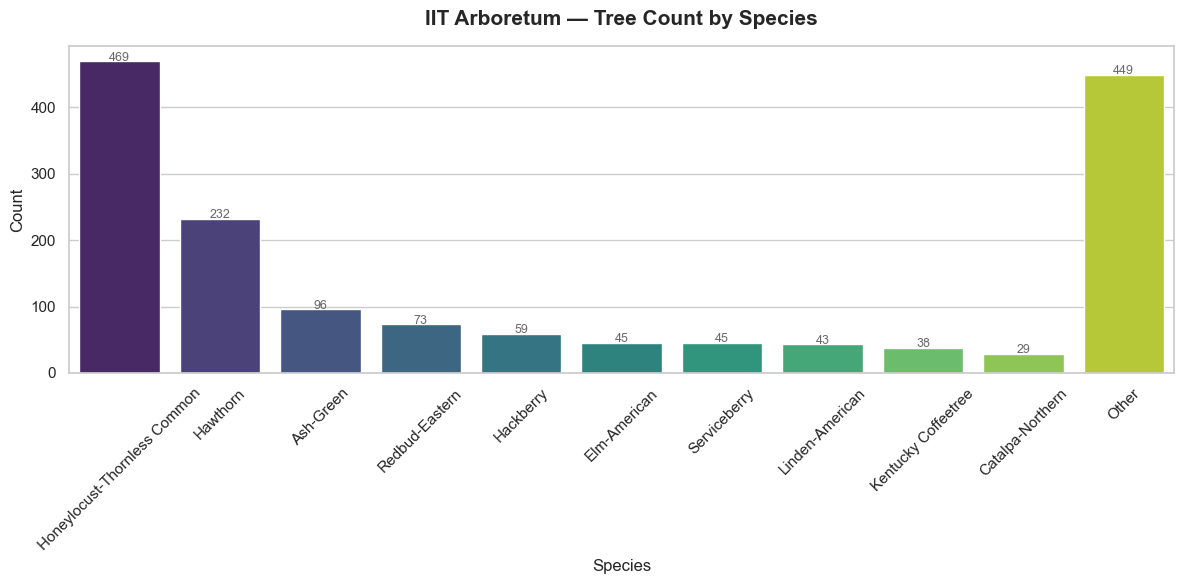

In [8]:
# --- Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    x=top_species.index,
    y=top_species.values,
    palette='viridis',
    ax=ax
)
ax.set_title('IIT Arboretum — Tree Count by Species', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
# Add count labels on top of each bar
for i, v in enumerate(top_species.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9, color='dimgray')
plt.tight_layout()
plt.show()

C:\Users\tomas\AppData\Local\Temp\ipykernel_27736\4177978697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


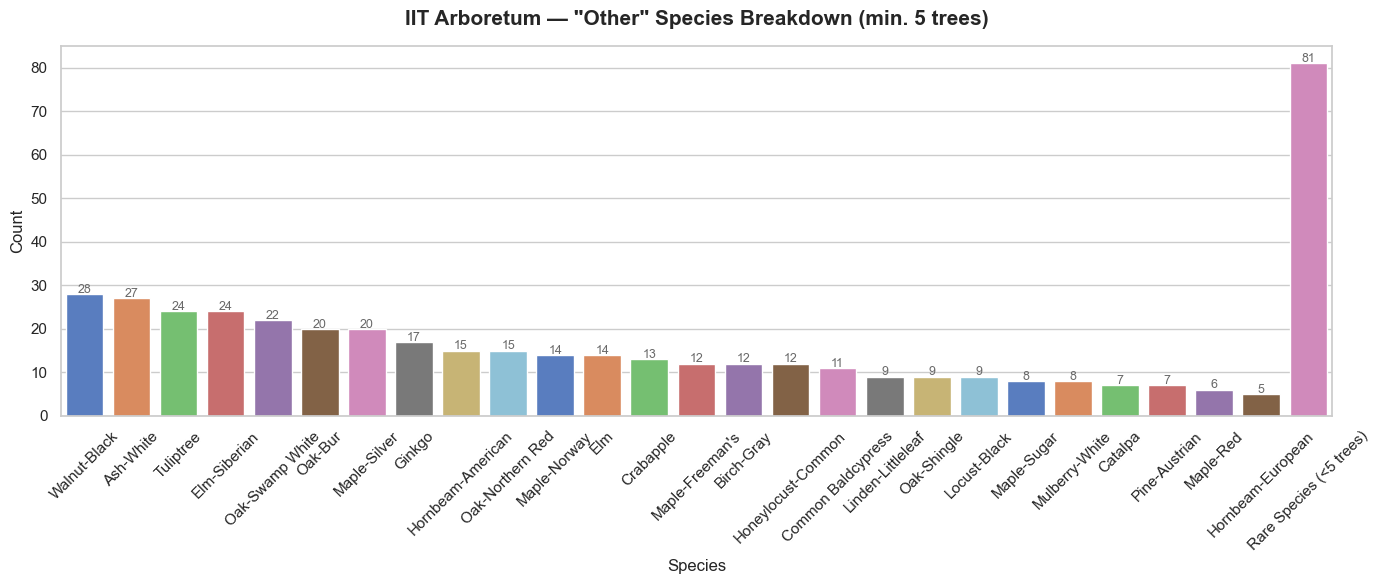

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    x=other_filtered.index,
    y=other_filtered.values,
    palette='muted',
    ax=ax
)
ax.set_title(f'IIT Arboretum — "Other" Species Breakdown (min. {min_count} trees)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(other_filtered.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=9, color='dimgray')
plt.tight_layout()
plt.show()

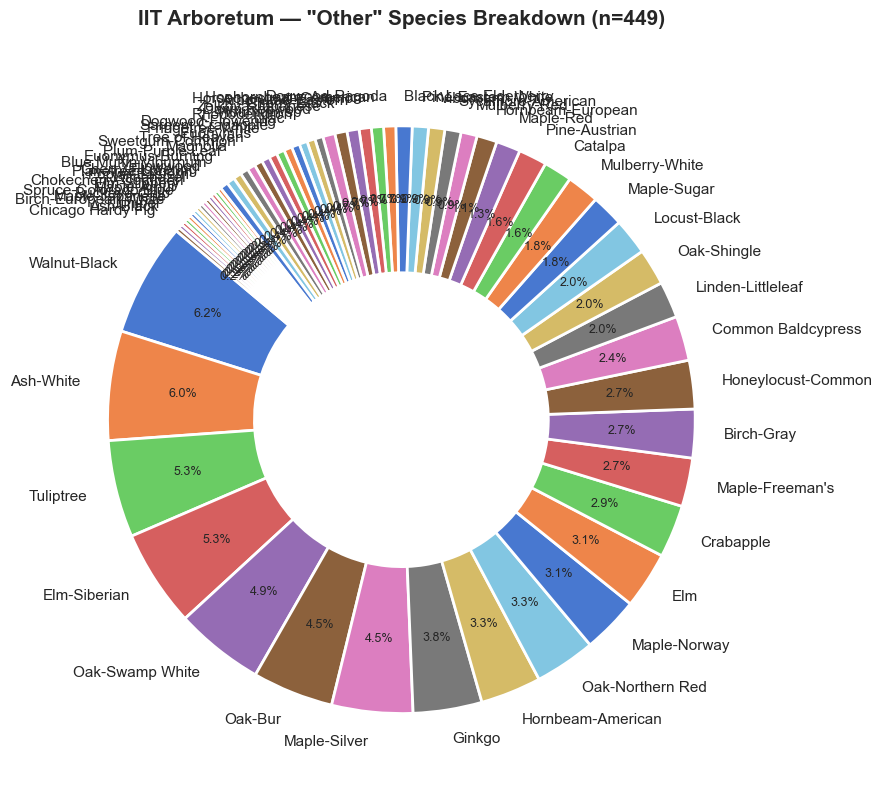

In [9]:
# --- Pie Chart for "Other" Species Breakdown ---
other_species = species_counts.iloc[top_n:]

palette_other = sns.color_palette('muted', len(other_species))

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    other_species,
    labels=other_species.index,
    colors=palette_other,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(9)
ax.set_title(f'IIT Arboretum — "Other" Species Breakdown (n={other_count})',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

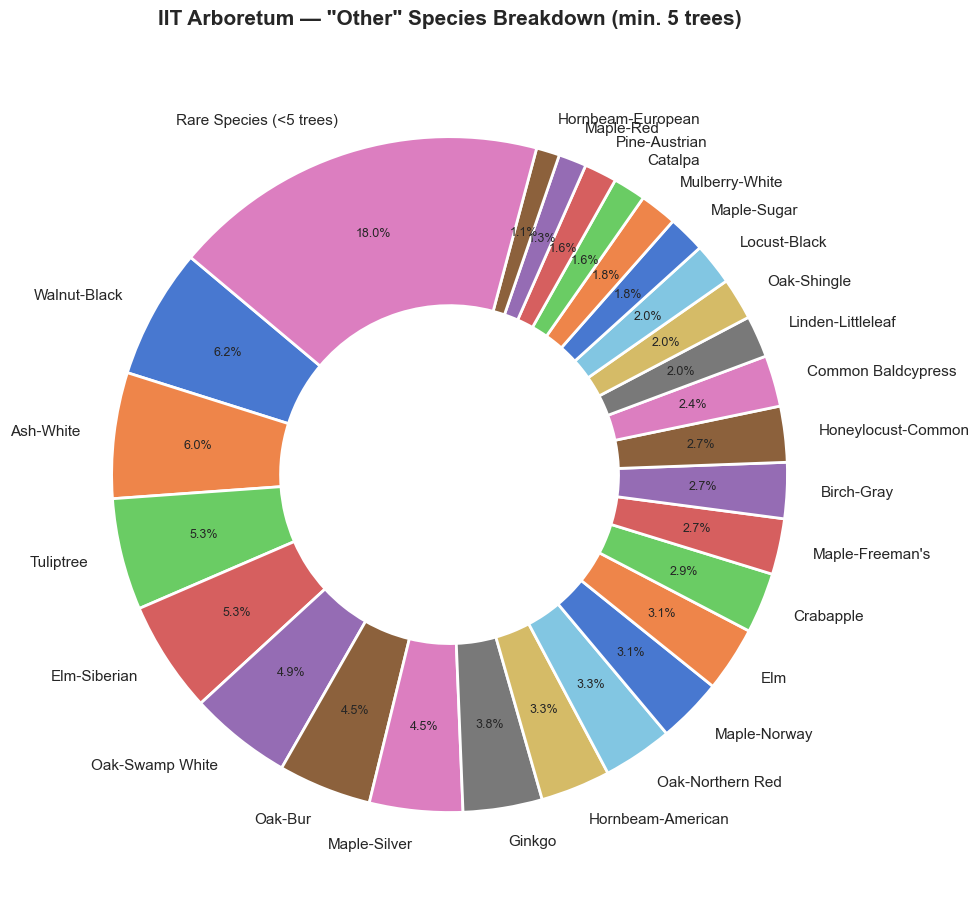

In [10]:
# Only show species with at least N trees, collapse rest into "Other"
min_count = 5 # adjust this threshold as needed

other_filtered = other_species[other_species >= min_count]
true_other = other_species[other_species < min_count].sum()
other_filtered['Rare Species (<5 trees)'] = true_other

palette_other = sns.color_palette('muted', len(other_filtered))

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    other_filtered,
    labels=other_filtered.index,
    colors=palette_other,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(9)
ax.set_title(f'IIT Arboretum — "Other" Species Breakdown (min. {min_count} trees)',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

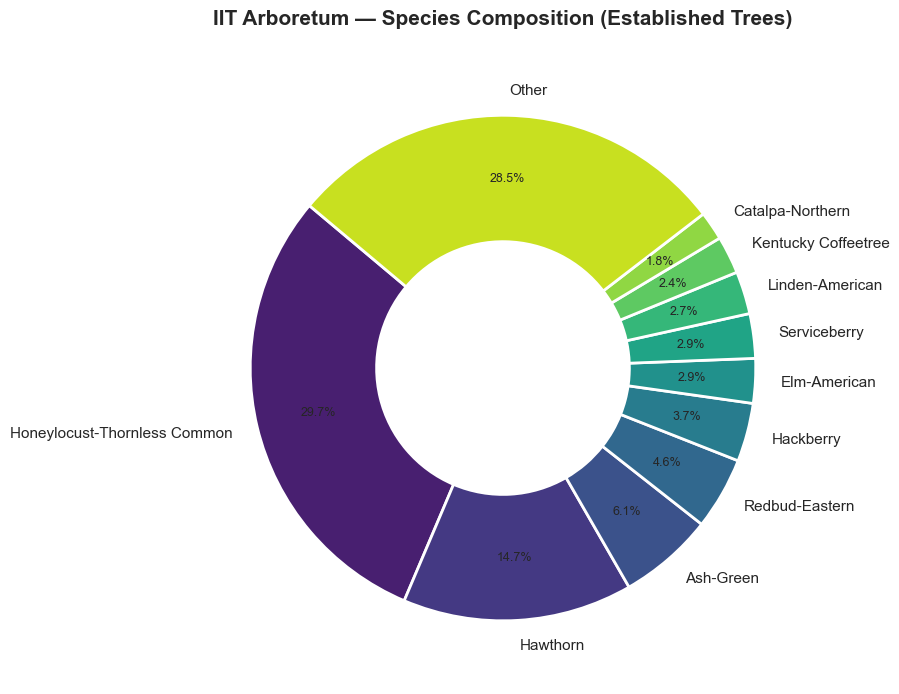

In [11]:
# --- Donut Chart (matplotlib, styled to match seaborn palette) ---
palette = sns.color_palette('viridis', len(top_species))
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    top_species,
    labels=top_species.index,
    colors=palette,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(9)
ax.set_title('IIT Arboretum — Species Composition (Established Trees)',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import folium
import seaborn as sns

df = pd.read_csv('iit_trees_corrected(filters).csv')
df_est = df[df['established'] == True].dropna(subset=['latitude', 'longitude'])

# Reuse top species from bar chart, drop the artificial "Other" entry
top_species_list = top_species.drop('Other').index.tolist()
df_map = df_est[df_est['common_name'].isin(top_species_list)]

# Build color map using same viridis palette as bar chart
palette = sns.color_palette('viridis', len(top_species_list))
def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(
        int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)
    )
color_map = {species: rgb_to_hex(palette[i]) for i, species in enumerate(top_species_list)}

# Base map
m = folium.Map(
    location=[df_map['latitude'].mean(), df_map['longitude'].mean()],
    zoom_start=16,
    tiles='CartoDB positron'
)

# Plot trees
for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=12,
        color=None,
        fill=True,
        fill_color=color_map[row['common_name']],
        fill_opacity=0.35,
        popup=folium.Popup(
            f"<b>{row['common_name']}</b><br>"
            f"{row['scientific_name']}<br>"
            f"DBH: {row['dbh_clean']}&quot;<br>"
            f"Cohort: {row['planting_cohort']}",
            max_width=200
        )
    ).add_to(m)

# Legend
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
<b>Top 10 Species</b><br>
"""
for species, color in color_map.items():
    legend_html += f'<i style="background:{color};width:12px;height:12px;display:inline-block;margin-right:6px;border-radius:50%;"></i>{species}<br>'
legend_html += "</div>"
m.get_root().html.add_child(folium.Element(legend_html))

m.save('iit_species_map.html')
m

In [17]:
print(df_est['common_name'].value_counts().to_string())
print(f"{df_est['common_name'].nunique()} different species in dataset.")

common_name
Honeylocust-Thornless Common    469
Hawthorn                        232
Ash-Green                        96
Redbud-Eastern                   73
Hackberry                        59
Elm-American                     45
Serviceberry                     45
Linden-American                  43
Kentucky Coffeetree              38
Catalpa-Northern                 29
Walnut-Black                     28
Ash-White                        27
Tuliptree                        24
Elm-Siberian                     24
Oak-Swamp White                  22
Oak-Bur                          20
Maple-Silver                     20
Ginkgo                           17
Hornbeam-American                15
Oak-Northern Red                 15
Maple-Norway                     14
Elm                              14
Crabapple                        13
Maple-Freeman's                  12
Birch-Gray                       12
Honeylocust-Common               12
Common Baldcypress               11
Linden-Littlelea

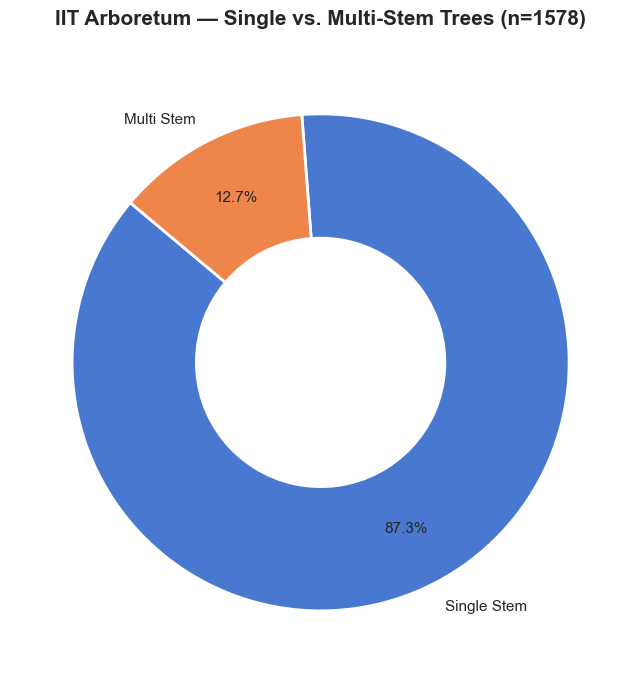

In [ ]:
stem_counts = df_est['is_multi_stem'].value_counts()
stem_counts.index = ['Single Stem', 'Multi Stem']

palette_stem = sns.color_palette('muted', 2)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    stem_counts,
    labels=stem_counts.index,
    colors=palette_stem,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(11)
ax.set_title(f'IIT Arboretum — Single vs. Multi-Stem Trees (n={len(df_est)})',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()